# Q3 — CALIPSO Comparison

**Figure:** CALIPSO L3 ice cloud occurrence — December 2016  
**Data:** `CAL_LID_L3_Ice_Cloud-Standard-V1-00.2016-12A.hdf`  
**Style:** matches Q1 ATL_TC__2A occurrence maps

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from pyhdf.SD import SD, SDC
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.ndimage import gaussian_filter, median_filter
from pathlib import Path

DATA_DIR = Path("/Users/tobiasraucher/Python/KNMI/data/v2_data")
OUT_DIR  = Path("/Users/tobiasraucher/Python/KNMI/output/figures")
OUT_DIR.mkdir(exist_ok=True)

MIN_COUNT    = 10
VMAX         = 0.25
SMOOTH_SIGMA = 1.5
MEDIAN_SIZE  = 3

In [13]:
# ── Load CALIPSO HDF4 ─────────────────────────────────────────────────────────
cal_path = DATA_DIR / "CAL_LID_L3_Ice_Cloud-Standard-V1-00.2016-12A.hdf"

f = SD(str(cal_path), SDC.READ)

lon_cal  = f.select("Longitude_Midpoint")[:]   # (144,)
lat_cal  = f.select("Latitude_Midpoint")[:]    # (85,)
alt_cal  = f.select("Altitude_Midpoint")[:]    # (172,)

ice_samp = f.select("Ice_Cloud_Samples")[:].astype(float)
cld_free = f.select("Cloud_Free_Samples")[:].astype(float)
wat_samp = f.select("Water_Cloud_Samples")[:].astype(float)
unk_samp = f.select("Unknown_Cloud_Samples")[:].astype(float)

f.end()

print(f"CALIPSO grid  : {lat_cal.shape[0]} lat × {lon_cal.shape[0]} lon × {alt_cal.shape[0]} alt")
print(f"Lat range     : {lat_cal.min():.1f} to {lat_cal.max():.1f}")
print(f"Lon range     : {lon_cal.min():.1f} to {lon_cal.max():.1f}")
print(f"Alt range     : {alt_cal.min():.2f} to {alt_cal.max():.2f} km")

CALIPSO grid  : 85 lat × 144 lon × 172 alt
Lat range     : -84.0 to 84.0
Lon range     : -178.8 to 178.8
Alt range     : -0.35 to 20.14 km


In [14]:
# ── Compute occurrence: lat/lon (column-integrated) ──────────────────────────
denom = ice_samp + cld_free + wat_samp + unk_samp

ice_col   = ice_samp.sum(axis=2)   # (85, 144)
denom_col = denom.sum(axis=2)

occ_cal = np.where(denom_col >= MIN_COUNT, ice_col / denom_col, np.nan)

# ── Compute occurrence: lat/height (zonal mean, averaged over longitude) ──────
# For each (lat, alt) cell: sum ice and denom over the longitude axis
ice_lh   = ice_samp.sum(axis=1)    # (85, 172)
denom_lh = denom.sum(axis=1)       # (85, 172)

occ_lh = np.where(denom_lh >= MIN_COUNT, ice_lh / denom_lh, np.nan)

# Restrict to 0–20 km
alt_mask = (alt_cal >= 0.0) & (alt_cal <= 20.0)
alt_plot = alt_cal[alt_mask]
occ_lh_plot = occ_lh[:, alt_mask]   # (85, n_alt)

/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_42917/1402361975.py:14: RuntimeWarning: invalid value encountered in divide
  occ_lh = np.where(denom_lh >= MIN_COUNT, ice_lh / denom_lh, np.nan)


In [15]:
# ── Print stats (unsmoothed) ──────────────────────────────────────────────────
def print_stats(arr, label):
    v = arr[~np.isnan(arr)]
    print(f"─── {label} ───")
    print(f"  Valid cells : {len(v):,} / {arr.size:,}  ({100*len(v)/arr.size:.1f}%)")
    print(f"  Min / Max   : {v.min():.4f} / {v.max():.4f}")
    print(f"  Mean        : {v.mean():.4f}")
    print(f"  Median      : {np.median(v):.4f}")
    print(f"  Std dev     : {v.std():.4f}")
    print(f"  p5 / p95    : {np.percentile(v,5):.4f} / {np.percentile(v,95):.4f}")
    print()

print_stats(occ_cal,     "CALIPSO L3  December 2016  lat/lon  (unsmoothed)")
print_stats(occ_lh_plot, "CALIPSO L3  December 2016  lat/height  (unsmoothed)")

─── CALIPSO L3  December 2016  lat/lon  (unsmoothed) ───
  Valid cells : 11,952 / 12,240  (97.6%)
  Min / Max   : 0.0000 / 0.4543
  Mean        : 0.0604
  Median      : 0.0481
  Std dev     : 0.0534
  p5 / p95    : 0.0015 / 0.1661

─── CALIPSO L3  December 2016  lat/height  (unsmoothed) ───
  Valid cells : 13,860 / 14,195  (97.6%)
  Min / Max   : 0.0000 / 0.3421
  Mean        : 0.0571
  Median      : 0.0138
  Std dev     : 0.0758
  p5 / p95    : 0.0000 / 0.2140



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Saved Q3_CALIPSO_occurrence_latlon_dec2016.png


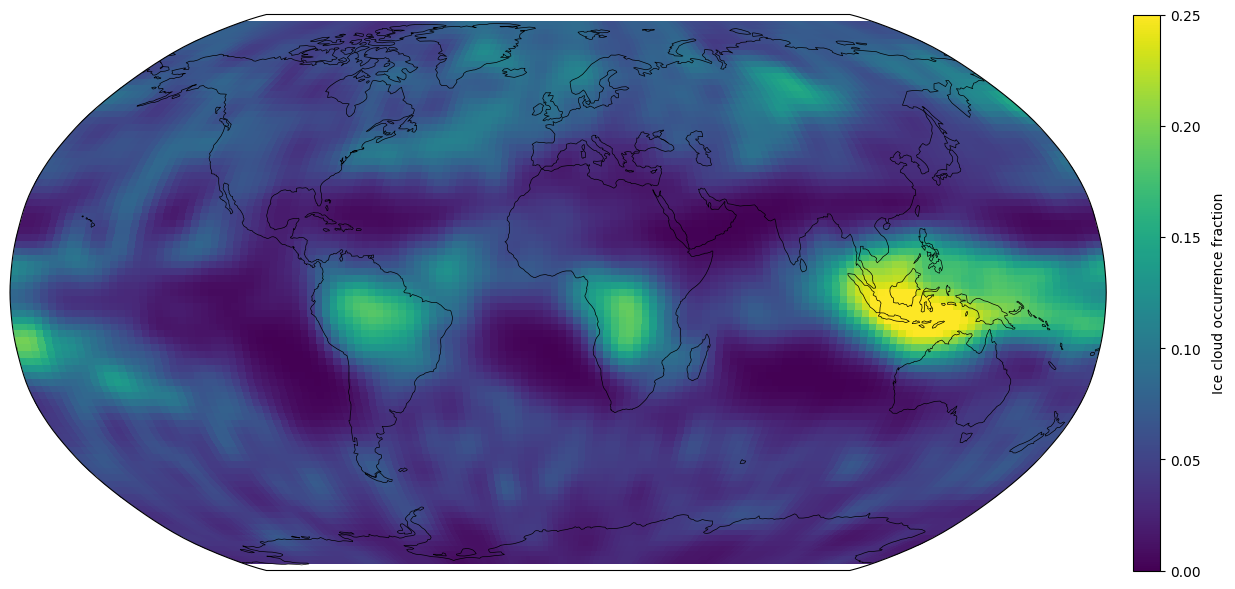

Saved Q3_CALIPSO_occurrence_latheight_dec2016.png


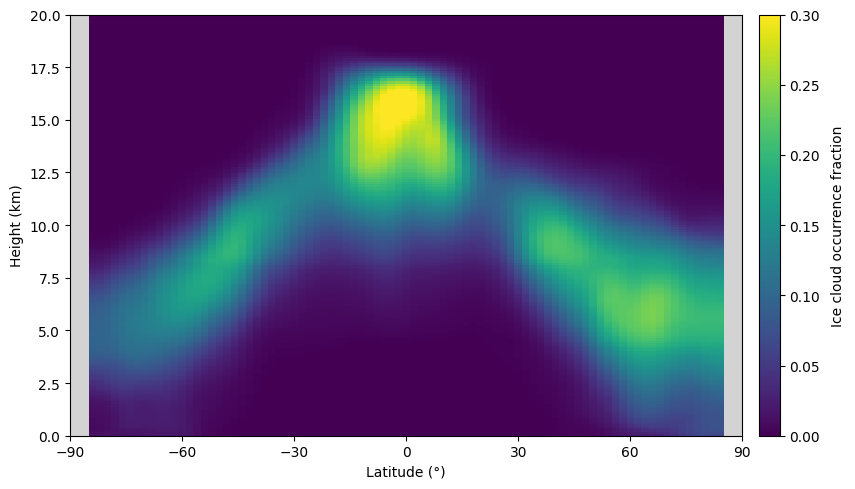

In [16]:
# ── Smooth both fields ────────────────────────────────────────────────────────
def smooth_map(data, sigma=SMOOTH_SIGMA, med_size=MEDIAN_SIZE):
    out = data.copy().astype(float)
    nan = np.isnan(out)
    filled = np.where(nan, np.nanmedian(out), out)
    out = np.where(nan, np.nan, median_filter(filled, size=med_size))
    nan = np.isnan(out)
    sv  = gaussian_filter(np.where(nan, 0., out), sigma=sigma)
    sw  = gaussian_filter((~nan).astype(float), sigma=sigma)
    return np.where(sw > 0.1, sv / sw, np.nan)

occ_cal_sm   = smooth_map(occ_cal)
occ_lh_sm    = smooth_map(occ_lh_plot, sigma=1.0)

VMAX_LH = 0.30

# ── Figure 1: lat/lon map ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 6))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="k")

im = ax.pcolormesh(
    lon_cal, lat_cal, occ_cal_sm,
    transform=ccrs.PlateCarree(),
    cmap="viridis", vmin=0, vmax=VMAX,
)
cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02, fraction=0.03)
cbar.set_label("Ice cloud occurrence fraction", labelpad=8)

plt.tight_layout()
plt.savefig(OUT_DIR / "Q3_CALIPSO_occurrence_latlon_dec2016.png", dpi=300, bbox_inches="tight")
print("Saved Q3_CALIPSO_occurrence_latlon_dec2016.png")
plt.show()

# ── Figure 2: lat/height zonal mean ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

im2 = ax.pcolormesh(
    lat_cal, alt_plot, occ_lh_sm.T,
    cmap="viridis", vmin=0, vmax=VMAX_LH, shading="auto",
)
cbar2 = plt.colorbar(im2, ax=ax, orientation="vertical", pad=0.02)
cbar2.set_label("Ice cloud occurrence fraction", labelpad=8)

ax.set_xlabel("Latitude (°)")
ax.set_ylabel("Height (km)")
ax.set_xlim(-85, 85)
ax.set_xticks(range(-90, 91, 30))
ax.set_ylim(0, 20)
ax.set_facecolor("lightgrey")

plt.tight_layout()
plt.savefig(OUT_DIR / "Q3_CALIPSO_occurrence_latheight_dec2016.png", dpi=300, bbox_inches="tight")
print("Saved Q3_CALIPSO_occurrence_latheight_dec2016.png")
plt.show()

## Q3.2 — Physical Properties: IWC and Temperature

In [17]:
# ── Load IWC and Temperature from CALIPSO HDF4 ───────────────────────────────
f = SD(str(cal_path), SDC.READ)

iwc_cal  = f.select("Ice_Water_Content_Median")[:].astype(float)  # (85, 144, 172), g m⁻³
temp_cal = f.select("Temperature_Mean")[:].astype(float)          # (85, 144, 172), °C
ice_acc  = f.select("Ice_Cloud_Accepted_Samples")[:].astype(float) # weights

f.end()

# ── Mask fill values (typically -9999) ───────────────────────────────────────
FILL = -9999.0
iwc_cal  = np.where((iwc_cal  <= FILL * 0.5) | (iwc_cal  < 0), np.nan, iwc_cal)
temp_cal = np.where((temp_cal <= FILL * 0.5),                           np.nan, temp_cal)
ice_acc  = np.where(ice_acc < 0, 0, ice_acc)

# Restrict to 0–20 km altitude and ice-containing cells only
iwc_cal_masked  = np.where(ice_acc > 0, iwc_cal,  np.nan)
temp_cal_masked = np.where(ice_acc > 0, temp_cal, np.nan)

print(f"IWC  valid pixels : {np.sum(~np.isnan(iwc_cal_masked)):,}")
print(f"Temp valid pixels : {np.sum(~np.isnan(temp_cal_masked)):,}")

IWC  valid pixels : 716,733
Temp valid pixels : 719,527


In [18]:
# ── IWC statistics (weighted by Ice_Cloud_Accepted_Samples) ──────────────────
def weighted_stats(values, weights, label):
    """Weighted percentiles and mean for a flattened masked array."""
    mask = ~np.isnan(values) & ~np.isnan(weights) & (weights > 0)
    v = values[mask]
    w = weights[mask]

    w_mean = np.average(v, weights=w)
    w_std  = np.sqrt(np.average((v - w_mean)**2, weights=w))

    # Weighted percentiles via sort
    sort_idx = np.argsort(v)
    v_s, w_s = v[sort_idx], w[sort_idx]
    cdf = np.cumsum(w_s) / w_s.sum()
    pcts = [5, 25, 50, 75, 95]
    p_vals = [v_s[np.searchsorted(cdf, p/100)] for p in pcts]

    print(f"─── {label} ───")
    print(f"  N cells (weighted > 0) : {mask.sum():,}")
    print(f"  Weighted mean          : {w_mean:.5f}")
    print(f"  Weighted std           : {w_std:.5f}")
    for p, pv in zip(pcts, p_vals):
        print(f"  p{p:<2}                    : {pv:.5f}")
    print()
    return w_mean, w_std, p_vals

iwc_mean, iwc_std, iwc_pcts = weighted_stats(
    iwc_cal_masked, ice_acc, "CALIPSO IWC (g m⁻³)  December 2016"
)

─── CALIPSO IWC (g m⁻³)  December 2016 ───
  N cells (weighted > 0) : 716,733
  Weighted mean          : 0.01179
  Weighted std           : 0.01677
  p5                     : 0.00015
  p25                    : 0.00192
  p50                    : 0.00751
  p75                    : 0.01599
  p95                    : 0.03730



In [19]:
# ── Temperature statistics and zone fractions ─────────────────────────────────
temp_mean, temp_std, temp_pcts = weighted_stats(
    temp_cal_masked, ice_acc, "CALIPSO Temperature (°C)  December 2016"
)

# Zone fractions (weighted by ice_acc)
mask = ~np.isnan(temp_cal_masked) & (ice_acc > 0)
t = temp_cal_masked[mask]
w = ice_acc[mask]
w_total = w.sum()

zones = {
    "Deep convective (T < -60°C)"    : t < -60,
    "Pure ice       (-60 to -38°C)"  : (t >= -60) & (t < -38),
    "Mixed-phase    (-38 to -20°C)"  : (t >= -38) & (t < -20),
    "Warm           (-20 to  0°C)"   : (t >= -20) & (t <   0),
    "Error          (T >= 0°C)"      : t >= 0,
}

print("─── CALIPSO Temperature Zone Fractions  December 2016 ───")
for name, sel in zones.items():
    frac = w[sel].sum() / w_total * 100
    print(f"  {name} : {frac:.1f}%")
print()

# EarthCARE reference for easy comparison
print("─── EarthCARE Reference  December 2025 ───")
for name, frac in [
    ("Deep convective (T < -60°C)",    20.4),
    ("Pure ice       (-60 to -38°C)",  40.6),
    ("Mixed-phase    (-38 to -20°C)",  35.1),
    ("Warm           (-20 to  0°C)",    4.0),
    ("Error          (T >= 0°C)",       0.004),
]:
    print(f"  {name} : {frac}%")

─── CALIPSO Temperature (°C)  December 2016 ───
  N cells (weighted > 0) : 719,527
  Weighted mean          : -48.89153
  Weighted std           : 16.86604
  p5                     : -80.01539
  p25                    : -58.99563
  p50                    : -48.33912
  p75                    : -36.79665
  p95                    : -22.43365

─── CALIPSO Temperature Zone Fractions  December 2016 ───
  Deep convective (T < -60°C) : 23.4%
  Pure ice       (-60 to -38°C) : 49.4%
  Mixed-phase    (-38 to -20°C) : 24.1%
  Warm           (-20 to  0°C) : 3.1%
  Error          (T >= 0°C) : 0.0%

─── EarthCARE Reference  December 2025 ───
  Deep convective (T < -60°C) : 20.4%
  Pure ice       (-60 to -38°C) : 40.6%
  Mixed-phase    (-38 to -20°C) : 35.1%
  Warm           (-20 to  0°C) : 4.0%
  Error          (T >= 0°C) : 0.004%
